In [1]:
import matplotlib.pyplot as plt
import numpy as np
from mpl_toolkits.axes_grid1 import make_axes_locatable
import matplotlib.ticker as ticker
from matplotlib.ticker import MaxNLocator
from matplotlib.ticker import (MultipleLocator, FormatStrFormatter,
                               AutoMinorLocator)
plt.rcParams.update({'font.size': 12})
import seaborn as sns
import cmath
import math 
from numpy.linalg import inv
from matplotlib.lines import Line2D
def custom_plot_single(fig, ax1, 
                       x_lst, y_lst, label_lst, xlim, ylim, label,pltname,
                       color=['k','r','b','g','o','c','m','y'],
                       linestyle=['solid','dashed','solid','dashed','solid','dashed'],
                       markertype=[None,None,'o','^','o','^'],
                       fillstyle=['none','none','none','none','full','full'],
                       linewidth=20*[3],
                       markevery=[450,30,50,40,56,72,63,95],
                       show_legend=True,
                       plt_outside=False, y_logscale = False, fontsize=30):
    
    fig.patch.set_facecolor('white')
    ax1.patch.set_facecolor('white')
    #color[len(x_lst)-1] = 'gray'
    for p in range(0, len(x_lst)):
        ax1.plot(x_lst[p], y_lst[p], color[p],
                 linewidth=linewidth[p],
                 linestyle=linestyle[p],
                 marker=markertype[p],
                 fillstyle=fillstyle[p],
                 markevery=markevery[p],
                 markersize=12,
                 label=label_lst[p])
    if(show_legend):
        ax1.legend(prop={'size': 24},loc='best',shadow=True, frameon=False)
        
    ax1.tick_params(which='minor', width=2, length=4, color='k')
    ax1.tick_params(which='major', width=2, length=8, color='k')

    ax1.xaxis.set_minor_locator(ticker.AutoMinorLocator())

    if (y_logscale):
        ax1.set_yscale('log')        
        ax1.yaxis.set_minor_locator(ticker.LogLocator(base=10.0, subs=np.arange(2, 10) * 0.1, numticks=10))
    else:
        ax1.yaxis.set_minor_locator(ticker.AutoMinorLocator())
        
    ax1.set_ylim(ylim[0],ylim[1])
    ax1.set_xlim(xlim[0],xlim[1])
    ax1.set_xlabel(label[0], fontsize=fontsize)#, fontdict=dict(weight='bold'))
    ax1.set_ylabel(label[1], fontsize=fontsize)#, fontdict=dict(weight='bold'))
    for tick in ax1.xaxis.get_major_ticks():
        tick.label1.set_fontsize(fontsize)

    for tick in ax1.yaxis.get_major_ticks():
        tick.label1.set_fontsize(fontsize)
    for spine in ax1.spines.values():
        spine.set_linewidth(2)  # Increase the frame thickness             
    if(plt_outside==False):
        plt.savefig(pltname, bbox_inches = "tight")
        
    return plt,pltname

PrintFigures=True
PointCharge=True


In [2]:
#quantum of conductance
#https://physics.nist.gov/cgi-bin/cuu/Value?conqu2e2sh
#G_quantum=2e^2/h, q=1.602e-19, h = 6.62607e-34

G_quantum  = 7.748091729e-5 #[S] 

num_CNTs = 1
Vds = 0.1
micron = 1e-6
nano = 1e-9
CNT_spacing = 2.556e-9
CNTs_per_micron = micron/CNT_spacing
pts_max  = 64

m=20
n=0
acc = 0.142e-9
gamma=2.5 #eV
Temp = 298.
def get_radius(acc,m,n):
    return acc*(np.sqrt(3.)/(2*np.pi))*np.sqrt(m**2 + m*n + n**2)
    
R_cnt = get_radius(acc,m,n)
print('Radius of CNT (nm):', R_cnt/nano)

Eg_min = acc*gamma/R_cnt
print('bandgap, Eg_min/(eV):', Eg_min)

Radius of CNT (nm): 0.7828870314989447
bandgap, Eg_min/(eV): 0.45344984105855446


In [3]:
import pandas as pd
folder_path = '../figures_exp/'
Fig1d = pd.read_csv(folder_path  + 'fig1d.csv', header=None)

Vgs_exp  = Fig1d[0].to_numpy()
Ids_exp  = Fig1d[1].to_numpy() 

In [54]:
foldername = [] 
label_str = []
Color = []
ZfromCNT = [] #0.3nm + Zoffset
Linestyle = []
Markertype = []
Markerevery = []
#for experimental data
label_str.append(r'experiment')
Color.append('r')
Markertype.append('None')
Markerevery.append(1)
Linestyle.append('solid')

#simulations
foldername.append('/global/cfs/cdirs/m3766/ELEQTRONeX/point_charge/topgate_CNTFET/no_charge/EfmDot2')
label_str.append(r'0 trap, $E_F=$-0.2 eV')
ZfromCNT.append('None')
Markertype.append('None')
Color.append('silver')
Markerevery.append(1)
Linestyle.append('dashed')


foldername.append('/global/cfs/cdirs/m3766/ELEQTRONeX/point_charge/topgate_CNTFET/singleCharge/EfmDot2/Zoff4dz')
label_str.append(r'1 trap, $E_F=$-0.2 eV')
ZfromCNT.append('0.3 nm')
Color.append('k')
Markertype.append('None')
Markerevery.append(1)
Linestyle.append('dotted')


foldername.append('/global/cfs/cdirs/m3766/ELEQTRONeX/point_charge/topgate_CNTFET/no_charge/Efm1')
label_str.append(r'0 trap, $E_F=$-1 eV')
ZfromCNT.append('None')
Markertype.append('^')
Color.append('silver')
Markerevery.append(2)
Linestyle.append('dashed')


foldername.append('/global/cfs/cdirs/m3766/ELEQTRONeX/point_charge/topgate_CNTFET/singleCharge/Efm1/Zoff4dz')
label_str.append(r'1 trap, $E_F=$-1 eV')
ZfromCNT.append('0.3 nm')
Color.append('k')
Markertype.append('o')
Markerevery.append(1)
Linestyle.append('dotted')


num_labels=np.size(label_str)
num_folders=np.size(foldername)


In [55]:
Vgs =  np.zeros((num_folders, pts_max),dtype=float)
G   = np.zeros((num_folders, pts_max),dtype=float)
Ids_appx = np.zeros((num_folders, pts_max),dtype=float)
pts = np.zeros(num_folders,dtype=int)
pts[:] = pts_max

In [56]:
for folder in range(num_folders):
    file_path = f"{foldername[folder]}/negf/NS_1/I.dat"
    print(str(folder) +  str(file_path))

    data = np.loadtxt(file_path, skiprows=1, usecols=(2, 7))  # Vgs = col[2], G = col[7]

    vgs_arr = np.array(data[:, 0])
    g_arr = np.array(data[:, 1])

    pts[folder] = len(vgs_arr)
    Vgs[folder][:pts[folder]] = vgs_arr
    G[folder][:pts[folder]] = g_arr
    Ids_appx[folder] =  G[folder]*G_quantum*Vds*(CNTs_per_micron)

0../simulations/no_charge/EfmDot2/negf/NS_1/I.dat
1../simulations/singleCharge/EfmDot2/Zoff4dz/negf/NS_1/I.dat
2../simulations/no_charge/Efm1/negf/NS_1/I.dat
3../simulations/singleCharge/Efm1/Zoff4dz/negf/NS_1/I.dat


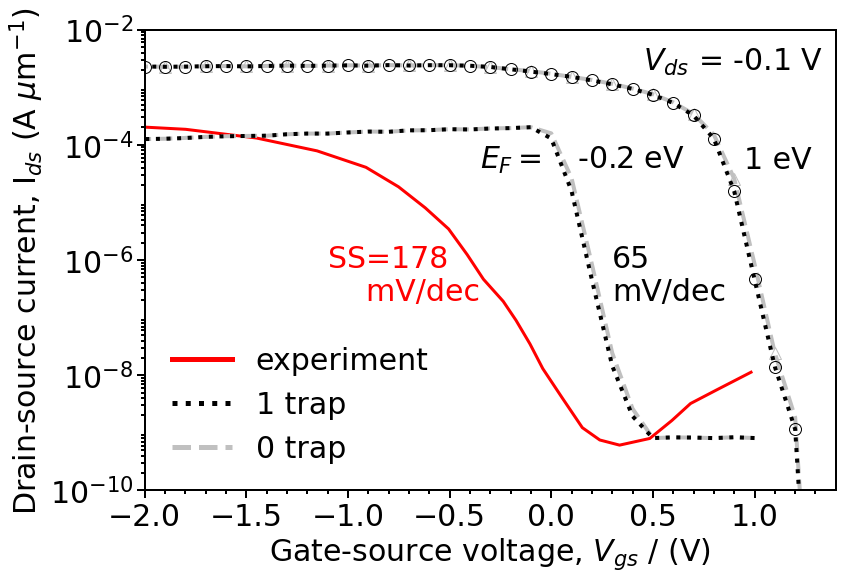

In [58]:
if(PrintFigures): 
   
    # Create a figure with a fixed size
    fig = plt.figure(figsize=(12, 8))
    ax = fig.add_axes([0.18, 0.15, 0.8, 0.8])    
    plt,pltname = custom_plot_single(fig,ax,
                                     [Vgs_exp] + [(Vgs[folder][0:pts[folder]]) for folder in range(num_folders)], 
                                     [Ids_exp] + [Ids_appx[folder][0:pts[folder]] for folder in range(num_folders)],
                                     [', '.join(label_str[folder].split(',')) for folder in range(num_labels)],
                                     [-2, 1.4],
                                     [1e-10,1e-2],
                                     [r'Gate-source voltage, $V_{gs}$ / (V)',
                                      r'Drain-source current, I$_{ds}$ (A $\mu$m$^{-1}$)'],
                                     'G_singleCharge_longCNT_EfmDot2.png',
                                     color=Color,
                                     linestyle=Linestyle,
                                     markertype=Markertype,
                                     markevery=Markerevery,
                                     linewidth=[3]+[4]*num_labels,
                                     fillstyle=['none']*num_labels,                                     
                       show_legend=False,
                       plt_outside=True, y_logscale=True) 
    #plt.text(-1.95,2e-5, r'$V_{ds}$ = -0.1 V', fontsize=30, color='k')
    plt.text(0.45,2e-3, r'$V_{ds}$ = -0.1 V', fontsize=30, color='k')
    plt.text(-1.1,2e-7, r'SS=178' +'\n'+'    mV/dec', fontsize=30, color='r')
    plt.text(0.3,2e-7, r'65'+'\n'+'mV/dec', fontsize=30, color='k')
    plt.text(-0.35,4e-5, r'$E_F=$   -0.2 eV', fontsize=30, color='k')
    plt.text(0.95,4e-5, r'1 eV', fontsize=30, color='k')

    # Add custom legend manually
    legend_handles = [
        Line2D([0], [0], color='r', linestyle='solid', lw=5, label='experiment'),  # Dotted line        
        Line2D([0], [0], color='black', linestyle=':', lw=5, label='1 trap'),  # Dotted line
        Line2D([0], [0], color='silver', linestyle='--', lw=5, label='0 trap')  # Dashed line
    ]  
    plt.legend(handles=legend_handles, loc='lower left', fontsize=30, frameon=False)    
    plt.savefig(pltname, bbox_inches = "tight", dpi='figure', format='png', pad_inches=0.1, facecolor='auto', edgecolor='auto')
   

## Calculation of SS and ON current is shown below is shown below.

### First read band structure and find at what voltage is the band edge in the channel kT and 4kT away from the Fermi level.


In [49]:
from scipy.interpolate import interp1d
from scipy.optimize import fsolve

num_rings=1664
E_f = -0.2 #eV
Scaling_Factor = Vds*G_quantum*CNTs_per_micron

In [32]:
print(f"num_folders: {num_folders}, pts_max: {pts_max}, num_rings: {num_rings}")
Y =  np.zeros((num_folders,pts_max,num_rings),dtype=float)
Qout  = np.zeros((num_folders,pts_max,num_rings),dtype=float)
U     = np.zeros((num_folders,pts_max,num_rings),dtype=float)
Ev  = np.zeros((num_folders,pts_max,num_rings),dtype=float)
Ec  = np.zeros((num_folders,pts_max,num_rings),dtype=float)

num_folders: 4, pts_max: 64, num_rings: 1664


In [33]:
for folder in range(num_folders):
    path = foldername[folder] + '/negf/NS_1/step'
    print(f"folder: {folder}, path: {path}")
    
    for f in range(pts[folder]):
        s=f
        fileQout = open(path+"%04d_Qout.dat"%(s))
        #print('fileQout',fileQout)
        lst = []
        counter=0
        for line in fileQout:    
            if (counter > 0 and counter < num_rings+1):
                lst += [line.split()]
            counter  = counter + 1
        y = [x[0] for x in lst]
        qout = [x[1] for x in lst]
        Y[folder][f] = np.asarray(y)
        Qout[folder][f] = np.asarray(qout)
        
        fileU = open(path+"%04d_U.dat"%(s))
        lst = []
        counter=0
        for line in fileU:    
            if (counter > -1 and counter < num_rings+1):
                lst += [line.split()]
            counter  = counter + 1
        u = [x[2] for x in lst]
        U[folder][f] = np.asarray(u)
        
        # fileNorm = open(path+"%04d_norm.dat"%(s))
        # lst = []
        # counter=0
        # for line in fileNorm:    
        #     if (counter > 0 and counter < num_rings+1):
        #         lst += [line.split()]
        #     counter  = counter + 1
        # #print(counter)
        # norm = [x[1] for x in lst]
        # Norm[folder][f] = np.asarray(norm)

Ev = -Eg_min/2. + U
Ec = Eg_min/2. + U

folder: 0, path: ../simulations/no_charge/EfmDot2/negf/NS_1/step
folder: 1, path: ../simulations/singleCharge/EfmDot2/Zoff4dz/negf/NS_1/step
folder: 2, path: ../simulations/no_charge/Efm1/negf/NS_1/step
folder: 3, path: ../simulations/singleCharge/Efm1/Zoff4dz/negf/NS_1/step


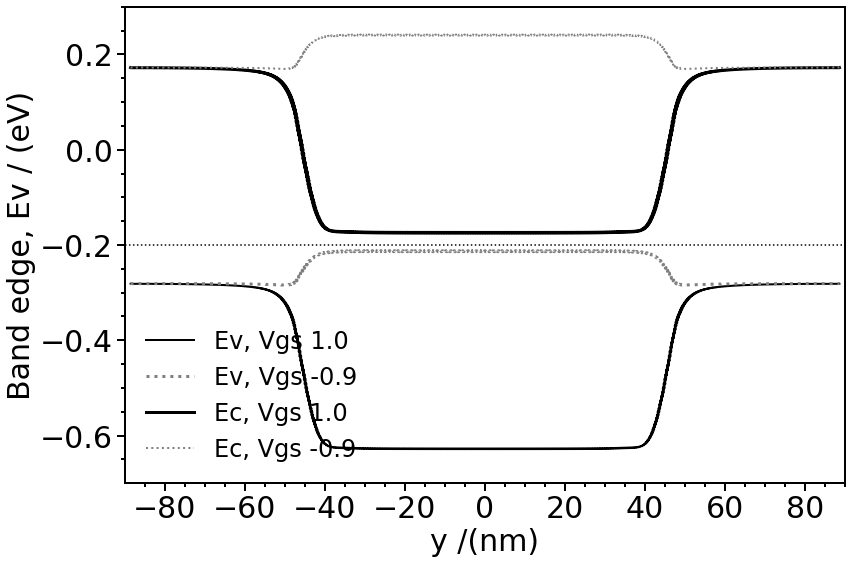

In [34]:
fig, ax = plt.subplots(1,1)
fig.set_size_inches(12,8)


if(PrintFigures):
    f=0 #folder
    i=0 #step 1 to plot bandstructure at
    j=19 # step 2 to plot bandstructure at
    delta=4 
    plt2,pltname = custom_plot_single(fig, ax,
                                     [Y[f][i], Y[f][j],Y[f][i], Y[f][j]], 
                                     [Ev[f][i], Ev[f][j],Ec[f][i], Ec[f][j]],
                                     [r'Ev, Vgs %.1f'%(Vgs[f][i]),r'Ev, Vgs %.1f'%(Vgs[f][j]),
                                      r'Ec, Vgs %.1f'%(Vgs[f][i]),r'Ec, Vgs %.1f'%(Vgs[f][j])],
                                     [-90,90],
                                     [-0.7,0.3],
                                     [r'y /(nm)',
                                      r'Band edge, Ev / (eV)'],
                                     'Ev.png',
                                     ['k','gray','k','gray','b'],
                                     linestyle=['solid','dotted','solid','dotted','solid','solid'],
                                     markertype=[None]*5,
                                     markevery=[1,1,1,1,1],
                                     linewidth=[2,3,3,2,2],
                       show_legend=True,
                       plt_outside=True, y_logscale=False)
    ax.axhline(y = E_f, color = 'k', linestyle = 'dotted')

fig.tight_layout()

In [35]:
##### # Function to find the x-value for given y-value
def find_x_for_y(target_y, x_range, f):
    # Define the equation f(x) - target_y = 0
    func = lambda x: f(x) - target_y
    # Use fsolve to find the root, with an initial guess
    x_root, = fsolve(func, np.mean(x_range))
    return x_root

def compute_barrier(U, Vgs, fig, ax, Ef=-0.2, a=5, b=8, Print=True, Eg=Eg_min):
    num_steps = np.size(Vgs)
    Ev = -Eg/2. + U
    Ec = Eg/2 + U
    #print(Ev[0][0])
    barrier = np.zeros(num_steps, dtype=float)
    phonon_jump = np.zeros(num_steps, dtype=float)
    
    for j in range(num_steps):
        mid = int(np.shape(Ev)[-1]/2)
        barrier[j] = Ef - Ev[j][mid]
        phonon_jump[j] = Ec[j][mid] - Ef
           # print(Ev[j][0])

    kT_eV = 0.0257025 #eV 1.38e-23*298/1.6e-19    

    f = interp1d(Vgs, barrier, kind='linear', fill_value='extrapolate')      
    #print(factor1*kT_eV, f(factor1*kT_eV))
    # Find x-values where f(x) equals kT_eV and 4*kT_eV
    x_akT_eV = find_x_for_y(a*kT_eV, Vgs, f)
    x_bkT_eV = find_x_for_y(b*kT_eV, Vgs, f)     
    g = interp1d(Vgs, phonon_jump, kind='linear', fill_value='extrapolate')
    x_dot2eV = find_x_for_y(0.2, Vgs, g)

    print('Vgs where barrier is ', a, 'kT:', x_akT_eV)
    print('Vgs where barrier is ', b, 'kT:', x_bkT_eV)
    print('Vgs where phonon-tunneling barrier is 0.2 eV:', x_dot2eV)
    
    import matplotlib.pyplot as plt

    if(Print):           
        xmin = Vgs[-1] - 0.1
        xmax = Vgs[0] + 0.1
        ymin = np.min(barrier)
        ymax = np.max(phonon_jump)
        plt,pltname = custom_plot_single(fig, ax,
                                         [Vgs],
                                         [barrier],
                                         [r'Transport barrier']                                          
                                         #[Vgs, Vgs],
                                         #[barrier, phonon_jump],
                                         #[r'Transport barrier', r'Phonon-tunneling barrier'] 
                                         + [None for s in range(num_steps)],
                                         [xmin,xmax],
                                         [ymin,ymax],
                                         [r'Vgs / (V)',
                                          r'Barrier / (eV)'],
                                         'Barrier.png',
                                         color = ['k','r'],
                                         linestyle=['solid','solid'],
                                         markertype=[None,None],
                                         markevery=[1,1,1,1,1,1,1,1,1,1,1,1],
                                         linewidth=[1,1,1,1,1,1,1,1,1,1,1,3,3],
                                         fillstyle=['none','none','none','none','none','none','none','none','none','none','none','none','none','none'],                                     
                                         show_legend=False,
                                         plt_outside=True, y_logscale=False) 
        

    
        ax.plot([xmin,x_akT_eV], [a*kT_eV,a*kT_eV], color='k', linestyle='--')     
        ax.plot([xmin,x_bkT_eV], [b*kT_eV,b*kT_eV], color='k', linestyle='--')     
    
        ax.plot([x_akT_eV,x_akT_eV], [ymin,a*kT_eV], color='k', linestyle='--')     
        ax.plot([x_bkT_eV,x_bkT_eV], [ymin,b*kT_eV], color='k', linestyle='--')     
        #ax.plot([x_dot2eV,x_dot2eV], [ymin,0.2], color='r', linestyle='--')     
        #ax.plot([xmin,x_dot2eV], [0.2,0.2], color='r', linestyle='--')     
        
        #plt.savefig(pltname, bbox_inches = "tight", dpi='figure', format='png', pad_inches=0.1, facecolor='auto', edgecolor='auto')
        
    return x_akT_eV, x_bkT_eV, x_dot2eV

In [36]:
def log_interp(Vgs, Ids, at_Vgs):

    # Log-transform the Ids
    log_Ids = np.log(Ids)
    
    # Create a linear interpolation function on the log-transformed data
    log_interp = interp1d(Vgs, log_Ids, kind='linear')
    
    # Interpolate to find the log of the interpolated value at at_Vgs
    log_interpolated_value = log_interp(at_Vgs)
    
    # Exponentiate to get back to the original scale
    interpolated_value = np.exp(log_interpolated_value)
    
    return interpolated_value


def compute_SS(Vgs, G, at_numer_Vgs, at_denom_Vgs, Print=True):
    Vds=0.1 #[V]
    G_0 = 7.748091729e-5 #[S]
    Scaling_Factor = Vds*G_0
    
    Ids = Scaling_Factor*G
    #print('\nVgs:', Vgs)
    #print('Ids:', Ids)
    dVg = at_denom_Vgs - at_numer_Vgs
    dlogI = np.log10(log_interp(Vgs, Ids, at_numer_Vgs)/log_interp(Vgs, Ids, at_denom_Vgs))
    SS = dVg*1e3/dlogI #mV/decade
    print('\tSS (mV/decade):', SS)

    return SS

In [41]:
print('Experimental ON current and SS:')
G_exp = Ids_exp/(G_quantum*Vds*CNTs_per_micron)
I_ON_exp = Scaling_Factor*Ids_exp[-1]
print('ON current / (1e-4 \mu A):', I_ON_exp*1e10)    
SS_exp = compute_SS(Vgs_exp, G_exp, -0.27, -0.0, True)

Experimental ON current and SS:
ON current / (1e-4 \mu A): 0.34169596291197935
	SS (mV/decade): 177.37388666530595


In [15]:
I_ON =  np.zeros(num_folders,dtype=float)
SS =  np.zeros(num_folders,dtype=float)


folder: 0
label: 0 trap, $E_F=$-0.2 eV
ON current / (1e-4 \mu A): 1257509.8312140738
Vgs where barrier is  7 kT: 0.1496248256159903
Vgs where barrier is  12 kT: 0.2931305451376491
Vgs where phonon-tunneling barrier is 0.2 eV: 0.2321343294421572
	SS (mV/decade): 65.57438277384627

folder: 1
label: 1 trap, $E_F=$-0.2 eV
ON current / (1e-4 \mu A): 1257703.8366407782
Vgs where barrier is  7 kT: 0.12550376394051815
Vgs where barrier is  12 kT: 0.27011669299321495
Vgs where phonon-tunneling barrier is 0.2 eV: 0.20664387038706677
	SS (mV/decade): 65.8575182908536

folder: 2
label: 0 trap, $E_F=$-1 eV
ON current / (1e-4 \mu A): 22859447.235123415
Vgs where barrier is  7 kT: 0.9497208529205882
Vgs where barrier is  12 kT: 1.0937767143151207
Vgs where phonon-tunneling barrier is 0.2 eV: 1.0326217373494515
	SS (mV/decade): 65.5226938026746

folder: 3
label: 1 trap, $E_F=$-1 eV
ON current / (1e-4 \mu A): 22862327.003176056
Vgs where barrier is  7 kT: 0.9254339303758561
Vgs where barrier is  12 kT

/usr/lib/python3/dist-packages/scipy/optimize/_minpack_py.py:175: RuntimeWarning: The iteration is not making good progress, as measured by the 
  improvement from the last ten iterations.
  warnings.warn(msg, RuntimeWarning)
/usr/lib/python3/dist-packages/scipy/optimize/_minpack_py.py:175: RuntimeWarning: The iteration is not making good progress, as measured by the 
  improvement from the last ten iterations.
  warnings.warn(msg, RuntimeWarning)


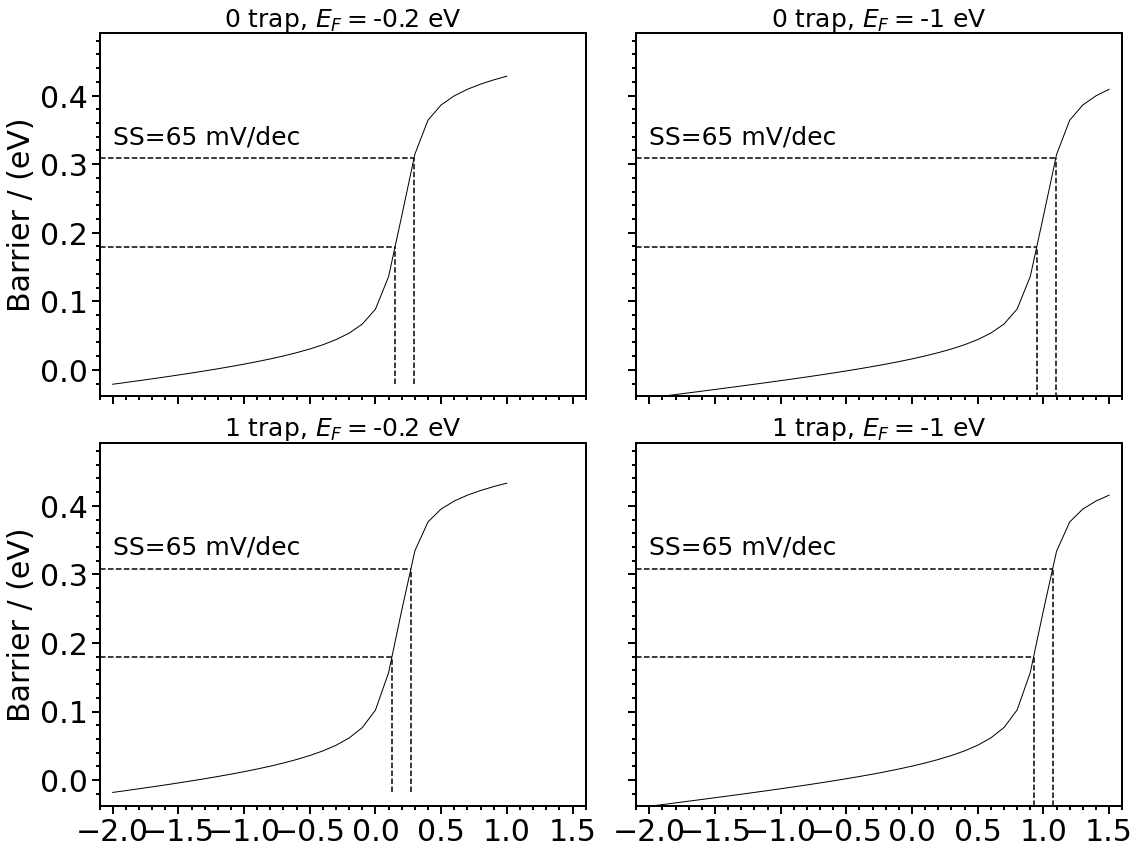

In [16]:
fig, ax = plt.subplots(2, 2, figsize=(16, 12), sharex=True, sharey=True)
#fig.set_size_inches(12,8)
for folder in range(4):
    print('\nfolder:', folder)
    print('label:', label_str[folder+1])        
    I_ON[folder] = Scaling_Factor*G[folder][pts[folder]-1]
    print('ON current / (1e-4 \mu A):', I_ON[folder]*1e10)    

    fig_idx_i = folder % 2
    fig_idx_j = folder // 2  
    ax_ij =  ax[fig_idx_i, fig_idx_j]
    if folder < 2:
        a = 7
        b = 12
        Ef=-0.2
        vgs_at_akT, vgs_at_bkT, vgs_at_phononBarrier = compute_barrier(U[folder][:pts[folder]], Vgs[folder][:pts[folder]], fig, ax_ij, Ef=Ef, a=a, b=b, Print=True) #avg    
    elif folder >= 2:
        a = 7
        b = 12
        Ef=-1
        vgs_at_akT, vgs_at_bkT, vgs_at_phononBarrier = compute_barrier(U[folder][:pts[folder]], Vgs[folder][:pts[folder]], fig, ax_ij, Ef=Ef, a=a, b=b, Print=True) #avg            
    
    SS[folder] = compute_SS(Vgs[folder][:pts[folder]], G[folder][:pts[folder]], vgs_at_akT, vgs_at_bkT, True)
    ax_ij.text(-2, 0.33, r'SS=%d'%(SS[folder]) + ' mV/dec', fontsize=25, color='k')
    ax_ij.set_title(f"{label_str[folder+1]}", fontsize=25)
    if fig_idx_j > 0:
        ax_ij.set_ylabel('')              
    if fig_idx_i < 3:
        ax_ij.set_xlabel('')
    
# Add labels for each column
plt.tight_layout(pad=1.0)  # Adjust padding to prevent overlap of axes labels and ticks
plt.savefig('TransportBarrier_SS_noTrap_1Trap.png', bbox_inches = "tight", dpi='figure', format='png', pad_inches=0.1, facecolor='auto', edgecolor='auto')
